# SPICE-posed synthetic lunar satellite imagery

Demo: pose a synthetic pinhole camera using the **real LRO spacecraft trajectory** (NAIF SPICE kernels) at the timestamp of a real LROC WAC image selected from a catalog-driven, illumination-filtered dataset search, then generate two candidate images that could stand in for real spacecraft imagery in terrain-relative navigation (TRN) testing: a synthetic 256x256 render from real Lunaserv WMS DEM/imagery via NASA's Ames Stereo Pipeline `sat_sim` (Phase 5), and the same real footprint's actual WAC image processed through ISIS3's own EDR-to-calibrated-cube pipeline (`isis_wac.py`, Phase 6). Validates each candidate's geometry against a common reference -- a real hillshade-based basemap -- two ways: a raw, north-up-rotated quality check, and a true pixel-for-pixel geo-registered overlay (the synthetic render via a CSM camera model and ASP's `mapproject`; the real WAC crop via ISIS's own native Pushframe camera model and `cam2map`, after `mapproject`'s CSM route turned out to have a real geometric bug for this sensor type -- see Phase 6's notes). Phase 7 then compares the two candidates directly against each other, with explicit SPICE-derived tie points. See `../docs/plan.md` for the full phase-by-phase approach and `../docs/data-sources.md` for the researched specifics referenced below.

This notebook drives the installed `trntest` package (see `../src/trntest/`) rather than duplicating its logic -- each cell is close to a one-line call into the package.

In [1]:
import dataclasses
import json

import trntest
from trntest import isis_wac, plotting, tie_points

session = trntest.Session()
session.config.output_dir.mkdir(parents=True, exist_ok=True)

## Phase 2: catalog-driven image selection + SPICE-derived camera pose

`session.select_dataset()` queries the real LROC catalog (via the PDS Geosciences Node ODE REST API) for a multi-orbit window with favorable illumination geometry and good WAC data availability, and returns a throttled, illumination-filtered image list (see `trntest.dataset`/`trntest.illumination`). `session.generate_dataset(images, limit=1)` then poses a pinhole camera for the first selected image, using LRO's real position/orientation (from NAIF SPICE kernels, in the `MOON_ME` frame) at that instant, and runs the rest of the pipeline (DEM/ortho fetch, `sat_sim` render) in one call. The DEM/ortho fetch AOI is sized to cover both the synthetic camera's own footprint *and* the real WAC crop's footprint (`GenerationResult.crop_footprint`, reused directly in Phase 6 below) in one request, so nothing displayed later runs past the edge of what was actually fetched here.

In [2]:
images = session.select_dataset(max_search_days=7)
images

select_dataset: 81 images across 12 orbits (2019-11-01 01:13:09.847000+00:00 to 2019-11-02 00:40:33.176000+00:00); per-orbit counts: {46625: 7, 46626: 7, 46627: 7, 46628: 7, 46629: 7, 46630: 7, 46631: 7, 46632: 7, 46633: 7, 46634: 7, 46635: 7, 46636: 7}


,product_id,edr_volume,edr_subdir,edr_doy,edr_product,cdr_volume,cdr_subdir,cdr_doy,cdr_product,orbit_number,start_time,stop_time,start_frame,center_frame_index,n_frames_for_square_crop,sun_elevation_deg,incidence_angle_deg,center_lat_deg,center_lon_deg
0,M1327210646CE,LROLRC_0041B,ESM4,2019305,M1327210646CE,LROLRC_1041B,ESM4,2019305,M1327210646CC,46625,2019-11-01 01:22:59.051000+00:00,2019-11-01 01:29:01.864000+00:00,93.5,129.0,71,41.844544,48.16,38.5020,169.5177
1,M1327211014CE,LROLRC_0041B,ESM4,2019305,M1327211014CE,LROLRC_1041B,ESM4,2019305,M1327210646CC,46625,2019-11-01 01:29:06.171000+00:00,2019-11-01 01:34:22.421000+00:00,75.0,110.0,70,28.650836,61.35,55.4504,171.8937
2,M1327211334CE,LROLRC_0041B,ESM4,2019305,M1327211334CE,LROLRC_1041B,ESM4,2019305,M1327210646CC,46625,2019-11-01 01:34:26.729000+00:00,2019-11-01 01:39:25.323000+00:00,69.5,105.0,71,15.823285,74.18,70.7112,177.0545
3,M1327215525CE,LROLRC_0041B,ESM4,2019305,M1327215525CE,LROLRC_1041B,ESM4,2019305,M1327215170CC,46625,2019-11-01 02:44:17.189000+00:00,2019-11-01 02:52:24.126000+00:00,259.5,294.0,69,19.388089,70.61,-67.5433,156.7774
4,M1327216016CE,LROLRC_0041B,ESM4,2019305,M1327216016CE,LROLRC_1041B,ESM4,2019305,M1327215525CC,46625,2019-11-01 02:52:28.428000+00:00,2019-11-01 02:57:51.396000+00:00,126.5,159.0,65,36.649340,53.35,-46.4285,161.8946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,M1327288708CE,LROLRC_0041B,ESM4,2019305,M1327288708CE,LROLRC_1041B,ESM4,2019305,M1327288003CC,46636,2019-11-01 23:04:00.714000+00:00,2019-11-01 23:10:23.683000+00:00,94.0,129.0,70,15.866035,74.14,70.9007,165.3437
77,M1327292971CE,LROLRC_0041B,ESM4,2019306,M1327292971CE,LROLRC_1041B,ESM4,2019306,M1327292540CC,46636,2019-11-02 00:15:03.961000+00:00,2019-11-02 00:22:22.711000+00:00,227.0,260.0,66,20.268884,69.73,-66.7155,145.0769
78,M1327293414CE,LROLRC_0041B,ESM4,2019306,M1327293414CE,LROLRC_1041B,ESM4,2019306,M1327292971CC,46636,2019-11-02 00:22:27.016000+00:00,2019-11-02 00:27:43.454000+00:00,132.0,166.0,68,36.628572,53.37,-46.9781,149.8148
79,M1327293735CE,LROLRC_0041B,ESM4,2019306,M1327293735CE,LROLRC_1041B,ESM4,2019306,M1327292971CC,46636,2019-11-02 00:27:47.758000+00:00,2019-11-02 00:36:07.133000+00:00,199.0,235.0,72,51.669499,38.33,-25.9000,151.8709


In [3]:
results = session.generate_dataset(images, limit=1)
result = results[0]

camera = result.camera
frame_timing = result.frame_timing
crop_footprint = result.crop_footprint
session = trntest.Session(config=result.config)

print(json.dumps(dataclasses.asdict(camera), indent=2, default=str))

ROI center (lon,lat deg): (np.float64(169.57576859858), np.float64(38.772670465555)), bbox (local m): (-126222.02784515591, -126552.58747697482, 138258.1387844415, 139801.45990725502)
ROI size 2645x2664 px (~100.0 m/px)


generate_dataset: 1 succeeded, 0 failed
{
  "et": 625843629.6404576,
  "center_frame_index": 129.0,
  "camera_center_moon_me_m": [
    -1436043.1493582418,
    265174.67205154215,
    1154372.7412624918
  ],
  "r_cam_to_me": [
    [
      0.22952225464154483,
      0.5055513562757797,
      0.8317074971358509
    ],
    [
      0.9711160733107735,
      -0.1762069034842235,
      -0.16088722547786674
    ],
    [
      0.06521584762713922,
      0.8446117174964015,
      -0.5313924537345752
    ]
  ],
  "boresight_rotation_k": 3,
  "slant_range_km": 124.8742959901997,
  "off_nadir_deg": 6.239135360774561,
  "focal_length_px": 215.57656937953163,
  "footprint_lonlat_deg": {
    "center": [
      169.57576859858,
      38.772670465555
    ],
    "top_left": [
      172.22481376184487,
      36.21440952440869
    ],
    "top_right": [
      166.42702536682637,
      36.58267090084799
    ],
    "bottom_left": [
      173.46626294760998,
      41.220810713854796
    ],
    "bottom_right": 

Sanity check: altitude and sub-spacecraft location should be consistent with LRO's known Fourth Extended Science Mission frozen elliptical orbit (low periapsis over the south pole).

In [4]:
print(f"Slant range to surface: {camera.slant_range_km:.2f} km")
print(f"Off-nadir angle: {camera.off_nadir_deg:.2f} deg")
print(f"Ground footprint center (lon, lat): {camera.footprint_lonlat_deg['center']}")

Slant range to surface: 124.87 km
Off-nadir angle: 6.24 deg
Ground footprint center (lon, lat): (np.float64(169.57576859858), np.float64(38.772670465555))


## Phase 3: DEM + ortho from Lunaserv WMS

Fetch `luna_wac_normalized_reflectance` (visible mosaic, despeckled and blended with a real-sun-lit hillshade -- see `docs/data-sources.md`) and `luna_wac_dtm_numeric_meters_absolute` (GLD100 DEM, converted from planetocentric radius to elevation) for the footprint above, through the local cache.

In [5]:
lunaserv_result = result.lunaserv_result
print(json.dumps(dataclasses.asdict(lunaserv_result), indent=2, default=str))

{
  "ortho": "/workspace/output/dataset/M1327210646CE/ortho_shaded.tif",
  "dem": "/workspace/output/dataset/M1327210646CE/dem_filled-tile-0.tif",
  "bbox": [
    -126222.02784515591,
    -126552.58747697482,
    138258.1387844415,
    139801.45990725502
  ],
  "width": 2645,
  "height": 2664
}


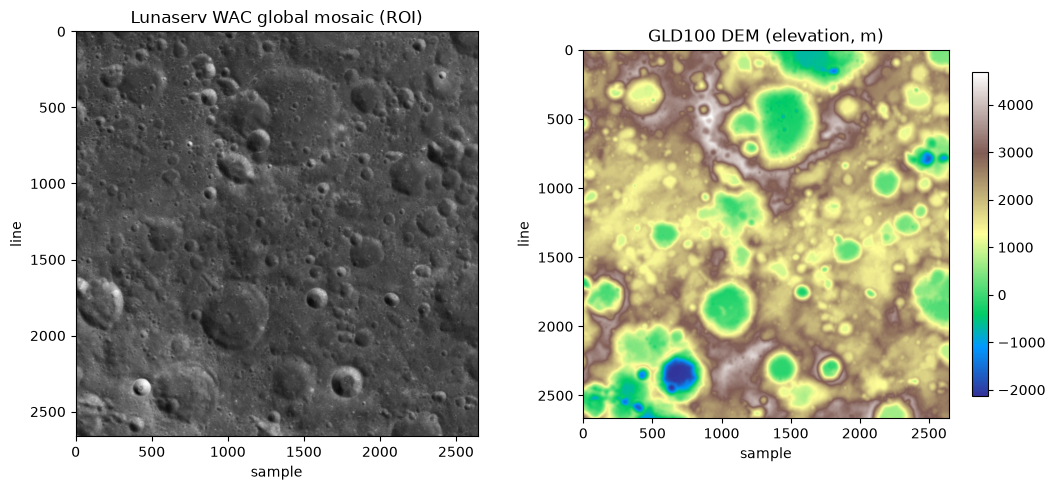

In [6]:
plotting.plot_dem_ortho(lunaserv_result);

### Camera footprint over the DEM

Plot the SPICE-derived camera's ground footprint (corners + center) on top of the ortho mosaic, to visually confirm the pose lands where expected.

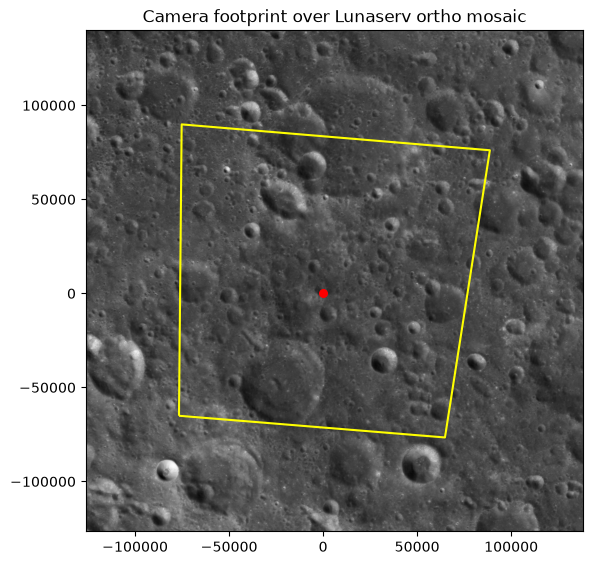

In [7]:
plotting.plot_camera_footprint(lunaserv_result, camera);

## Phase 4: render with `sat_sim` + the real camera pose

`session.generate_dataset()` already called `run_sat_sim(camera, lunaserv_result)` above, which:
1. Calls `sat_sim --camera-list` with the Phase 2 `.tsai` camera against the Phase 3 DEM/ortho, producing the synthetic 256x256 image.
2. Calls ASP's `cam_gen` to convert that exact camera to a CSM Frame model-state JSON (the "ISD" sidecar) -- `--save-as-csm` is a no-op in `--camera-list` mode, see `docs/data-sources.md`.

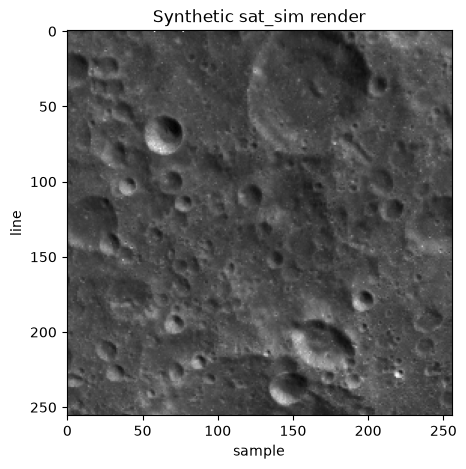

In [8]:
render_result = result.render_result
plotting.plot_synthetic_render(render_result.rendered_tif);

### The CSM / "ISD" JSON sidecar

The state file's first line is a bare model-name string (not JSON) -- standard CSM "state string" convention; skip it before parsing.

In [9]:
model_name, csm_state = trntest.read_csm_state(render_result.csm_json)

print('Model name:', model_name)
for key in ['m_focalLength', 'm_nLines', 'm_nSamples', 'm_ccdCenter', 'm_currentParameterValue']:
    print(f'{key}: {csm_state[key]}')

Model name: USGS_ASTRO_FRAME_SENSOR_MODEL
m_focalLength: 215.57656937953163
m_nLines: 256
m_nSamples: 256
m_ccdCenter: [128.0, 128.0]
m_currentParameterValue: [-1436043.149392029, 265174.67202685017, 1154372.7413076914, 0.69590258155889, 0.5304864031430712, 0.3222158419225806, 0.3612211570134317]


`m_currentParameterValue`'s first 3 entries are the camera center (X, Y, Z, meters, MOON_ME frame) and the last 4 are the orientation quaternion -- matching the `C`/`R` we computed from SPICE in Phase 2.

### North-up rotation (display only)

The sensor model's own pixel axes are a **fixed, hardware-motivated** choice -- not something that should vary by pass (see `camera.boresight_rotation_k`'s docstring and `docs/data-sources.md`'s "Pass-dependent sensor axis convention") -- but *which way is north* in that fixed convention depends on this specific pass (ascending vs. descending, plus any yaw state), so it's computed here purely for display, and reused throughout Phases 5-7 below. `trntest.orientation` picks, for each image independently, the multiple of 90 degrees (no mirroring) whose on-screen "up" is closest to true north, and this is applied only to the plotted arrays below -- the `.tsai`, the CSM/ISD JSON, and any pixel coordinates computed elsewhere are untouched.

Since the synthetic render and the real WAC crop already share the same fixed axis convention, we expect -- and confirm below -- that they need the *same* rotation here.

In [10]:
rotations = session.compute_display_rotations(camera, frame_timing)
print(f"synthetic: rotate {rotations.k_synthetic*90} deg for north-up (residual {rotations.dev_synthetic_deg:.1f} deg from true north)")
print(f"real crop: rotate {rotations.k_crop*90} deg for north-up (residual {rotations.dev_crop_deg:.1f} deg from true north)")

synthetic: rotate 180 deg for north-up (residual 8.2 deg from true north)
real crop: rotate 0 deg for north-up (residual 4.5 deg from true north)


### Tie points (display only)

`session.select_tie_points()` finds the real ground area both the synthetic render and the real WAC crop cover (each image's own footprint, an inscribed axis-aligned lon/lat box per image, intersected -- an approximate estimate, used only to pick plausible candidate points, not to place them), picks 5 points in a die's "5"/X pattern (4 corners + center, 10% margin from the shared area's edges), and projects each into the synthetic image's exact pixel coordinates (closed-form pinhole, the same fixed pose that rendered it). The real WAC crop's own pixel coordinates (`crop_px`) aren't resolved here yet -- that needs the real crop cube to exist first (Phase 6, below), and now goes through a genuine ISIS `campt` ground-to-image query against it, not a hand-rolled approximation (see `tie_points.py`'s module docstring). Reused throughout Phases 5-7 below: on the render panels of 5A/6A (marking the same 5 real ground points on each candidate's own raw image), and for the direct comparison in Phase 7.

In [11]:
tie_point_results = session.select_tie_points(camera, frame_timing)
for name, r in tie_point_results.items():
    print(f"{name:12s} lonlat={r['lonlat']}  synthetic_px={r['synthetic_px']}")

top_left     lonlat=(np.float64(167.67582369958822), np.float64(40.45508449360697))  synthetic_px=(np.float64(206.34855117596027), np.float64(205.19120576490823))
top_right    lonlat=(np.float64(171.7684928058868), np.float64(40.45508449360697))  synthetic_px=(np.float64(53.023948963118755), np.float64(217.39927895932027))
center       lonlat=(np.float64(169.72215825273753), np.float64(38.88229002307635))  synthetic_px=(np.float64(122.54503971066512), np.float64(134.15087511846247))
bottom_left  lonlat=(np.float64(167.67582369958822), np.float64(37.309495552545734))  synthetic_px=(np.float64(203.18671341450715), np.float64(43.384890567848245))
bottom_right lonlat=(np.float64(171.7684928058868), np.float64(37.309495552545734))  synthetic_px=(np.float64(28.16740724046589), np.float64(58.624406241058225))


## Phase 5: does the synthetic render's geometry check out?

This demo's actual goal is generating synthetic images that could stand in for real spacecraft imagery in terrain-relative navigation (TRN) testing -- so the real question for each candidate TRN test image (the synthetic render here; the real, ISIS-processed WAC crop in Phase 6) is whether its geometry genuinely matches reality, not just whether it looks plausible. Both phases check this two ways against the same reference -- the hillshade-based ortho basemap (`lunaserv_result.ortho`), Phase 3's own best available geometry reference:

- **A: raw image quality.** The render's own unprojected pixels, rotated north-up and scaled to real km, next to a plain crop of the basemap covering the same real footprint, both marked with the same 5 tie points -- a quick, ad hoc look at whether the render's content and rough position/scale make sense (`plotting.plot_render_vs_basemap`).
- **B: pixel-for-pixel alignment.** The render reprojected onto the map through its own real camera model (`mapproject`) and overlaid directly on the basemap -- true geo-registration, not just visual similarity (`plotting.plot_overlay`).

(Phase 7, below, is just 5A's and 6A's own render panels put together directly, for an easier side-by-side look at the two candidates themselves.)

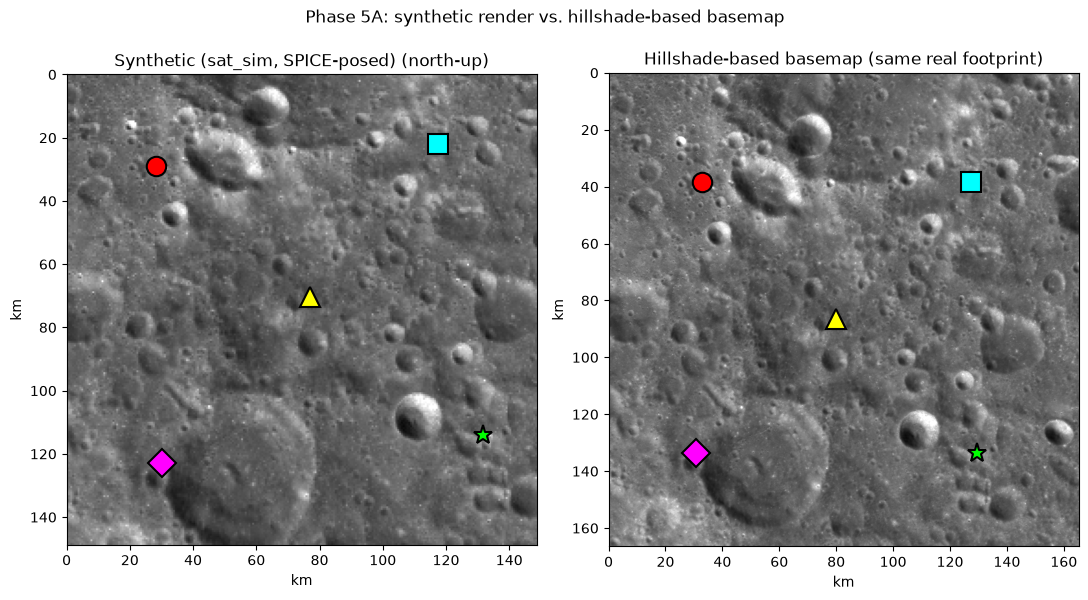

In [12]:
plotting.plot_render_vs_basemap(
    plotting.read_raster_band(render_result.rendered_tif),
    rotations.k_synthetic,
    camera.cross_track_width_km,
    camera.cross_track_width_km,
    camera.footprint_lonlat_deg,
    lunaserv_result.ortho,
    title="Phase 5A: synthetic render vs. hillshade-based basemap",
    render_label="Synthetic (sat_sim, SPICE-posed)",
    tie_point_results=tie_point_results,
    render_px_key="synthetic_px",
);

`render.run_mapproject`'s `--ref-map` (see `render.run_mapproject_image`) reprojects the synthetic render through the exact CSM/ISD sidecar `cam_gen` already produced for it (`render_result.csm_json`) -- the geometric inverse of `sat_sim`'s own forward DEM+camera-to-image render, through that same camera model -- onto the same DEM the render came from, so the result shares an exact pixel grid with `lunaserv_result.ortho` with no separate alignment step. `plotting.plot_overlay()` displays both with `rioxarray`, using each file's own real geographic coordinates rather than pixel indices.

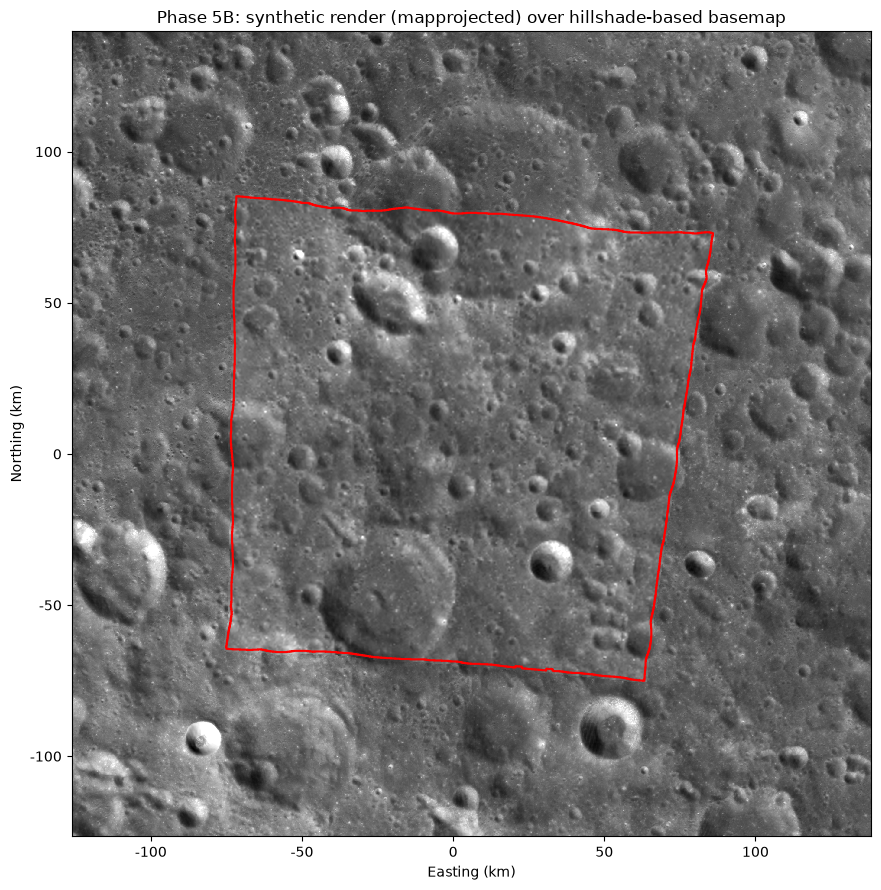

In [13]:
synthetic_mapproj_tif = session.run_mapproject(render_result, lunaserv_result)
plotting.plot_overlay(
    lunaserv_result.ortho,
    synthetic_mapproj_tif,
    title="Phase 5B: synthetic render (mapprojected) over hillshade-based basemap",
);

## Phase 6: does the real, ISIS-processed WAC crop's geometry check out?

The same two-style geometry check as Phase 5, for the other TRN test image candidate: a roughly square center crop of the product's real WAC EDR, processed through ISIS3's own pipeline instead of `sat_sim`. WAC is a push-frame camera: each 78-line frame multiplexes 7 filters (2 UV @ 4 TDI lines + 5 VIS @ 14 TDI lines), and getting a usable, calibrated image out of the raw EDR takes real processing. `isis_wac.run_pipeline()` steps the product's real EDR through ISIS3's own pipeline (`lrowac2isis` -> `spiceinit web=yes` -> `lrowaccal` -> `framestitch`) -- calibrated, band-separated, and framelet-interleaved through a genuine camera-model-aware toolchain, not a hand-derived byte offset. `flip` (`camera.reverse_crop_along_track`, the same real SPICE-derived per-pass yaw-state signal used throughout this notebook, not a fixed per-product constant) is passed explicitly now, not derived from a `Camera` object -- `session.generate_dataset()` above already ran this exact pipeline once internally, to pose `camera`'s own boresight at this crop's real, ISIS-determined center (see `camera.build_camera`'s docstring); `run_pipeline` is idempotent, so this call just reuses that same stitched cube rather than redoing the work.

`isis_wac.crop_for_camera()` then crops `stitched` (via ISIS's own `crop` app) down to the real-footprint frame range (`camera.center_frame_index` +/- half of `camera.n_frames_for_square_crop`) -- a single, real "WAC crop" cube that both 6A (raw display, right below) and 6B (mapprojected, further below) derive from, the same way 5A/5B both already derive from one synthetic render with no special-casing. `crop_footprint` (from Phase 2's `result.crop_footprint` -- `tie_points.crop_footprint_corners_for_camera`'s independent ray-trace of that same crop's real ground footprint, computed inside `generate_dataset()` since it's also needed there to size the DEM/ortho fetch) is what `plot_render_vs_basemap` crops the matching basemap area to.

Unlike 5B, 6B does *not* go through ASP's `mapproject` via a CSM/ISD sidecar. That path was tried extensively and abandoned: investigation traced its bad geometry to a real bug in `usgscsm`'s `UsgsAstroPushFrameSensorModel::groundToImage` (the function `mapproject` calls once per output pixel) -- an unbracketed secant search over framelet index that's unreliable for Pushframe images, badly so for a short crop. Confirmed independent of any ISD authoring choice (varying every plausible ISD field made no difference), confirmed via a chained-iteration round-trip test that never converges to a stable answer for the crop, and confirmed even the long-trusted *full-cube* reference used throughout this notebook's earlier validation is itself measurably affected (~0.2-0.4 correlation against ISIS's own native reprojection, despite the two using literally the same source pixels). `isis_wac.run_cam2map_for_crop()` instead uses ISIS's own native camera model via `cam2map` -- confirmed self-consistent regardless of crop size (crop vs. full cube agree to 0.9999986 correlation) and independently checked against `pyproj`'s own math to sub-micrometer precision. See `docs/history.md`'s dated entry for the full investigation.

In [14]:
stitched = isis_wac.run_pipeline(camera.reverse_crop_along_track, frame_timing, session.config)
wac_crop = isis_wac.crop_for_camera(stitched, camera, session.config)

`isis_wac.resolve_ground_to_image_model()` decides which camera-model authority the real crop's own tie points should be queried against: try a CSM ISD sidecar first (`isd_generate`, same tool 5B's `mapproject` uses), and only fall back to the crop's native, SPICE-embedded camera model if the ISD resolves to a Pushframe sensor model -- the class `mapproject`'s `groundToImage` is known unreliable for (see 6B's notes above). For WAC-VIS this always takes the fallback branch, but the decision itself is real (derived from the ISD's own `name_model`), not hardcoded. `tie_points.resolve_crop_pixels()` then queries each tie point's real pixel location in `wac_crop` via ISIS's own `campt` -- a genuine ground-to-image lookup through a validated tool, replacing the deprecated SPICE-only approximation `select_tie_points` used to compute this same value with (see `tie_points.py`'s module docstring for the measured discrepancy this fixes). A die5 point the real camera doesn't actually see (the approximate footprint used to pick candidate points can be off enough for this to happen for real, e.g. near the poles) is dropped with a printed warning rather than breaking the run.

In [15]:
ground_to_image_model = isis_wac.resolve_ground_to_image_model(stitched, wac_crop, session.config)
tie_point_results = tie_points.resolve_crop_pixels(tie_point_results, ground_to_image_model)
for name, r in tie_point_results.items():
    print(f"{name:12s} crop_px={r['crop_px']}")

top_left     crop_px=(112.6033934105, 182.65192423848)
top_right    crop_px=(584.46520321057, 128.94680371408)
center       crop_px=(368.45306232699, 467.68430429816)
bottom_left  crop_px=(136.24958315717, 808.82830263613)
bottom_right crop_px=(628.30055861222, 755.85395469191)


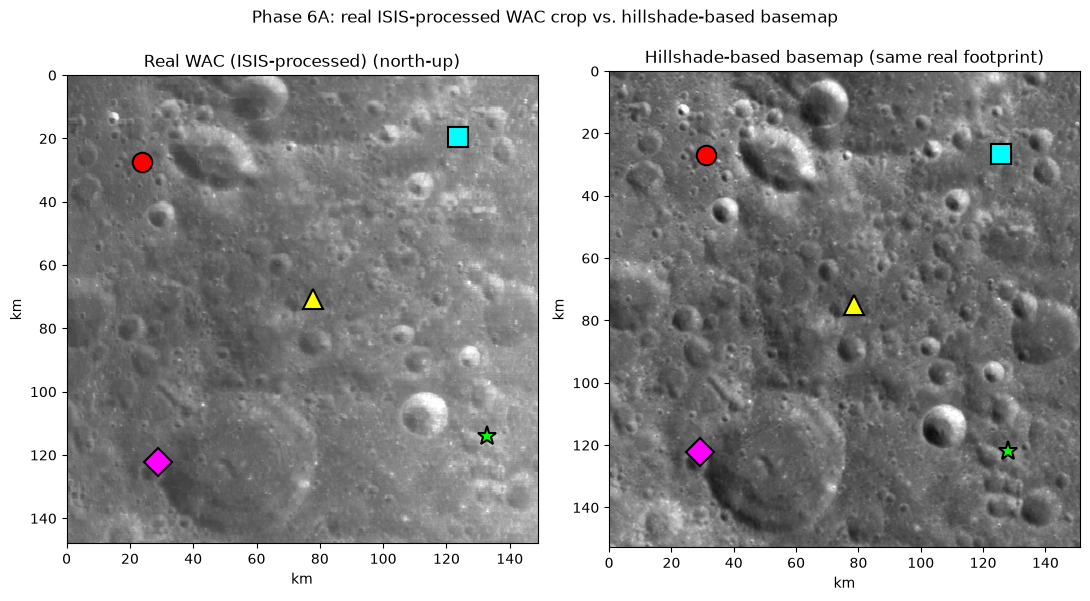

In [16]:
crop_width_km = camera.cross_track_width_km
crop_height_km = camera.n_frames_for_square_crop * camera.km_per_frame
plotting.plot_render_vs_basemap(
    plotting.read_raster_band(wac_crop.cub_path),
    rotations.k_crop,
    crop_width_km,
    crop_height_km,
    crop_footprint,
    lunaserv_result.ortho,
    title="Phase 6A: real ISIS-processed WAC crop vs. hillshade-based basemap",
    render_label="Real WAC (ISIS-processed)",
    tie_point_results=tie_point_results,
    render_px_key="crop_px",
);

`isis_wac.run_cam2map_for_crop()` reprojects `wac_crop` onto the map via ISIS's own native `cam2map`, using a map file cloned from `lunaserv_result`'s own local Orthographic projection (`isis_wac._orthographic_map_pvl`) so the output lands in the same real-world coordinate system as `lunaserv_result.ortho` -- the real-WAC counterpart to 5B's `mapproject`, sharing `plotting.plot_overlay` (no special-casing needed since `wac_crop` -- unlike the old full `stitched` cube -- already covers just the real footprint being compared).

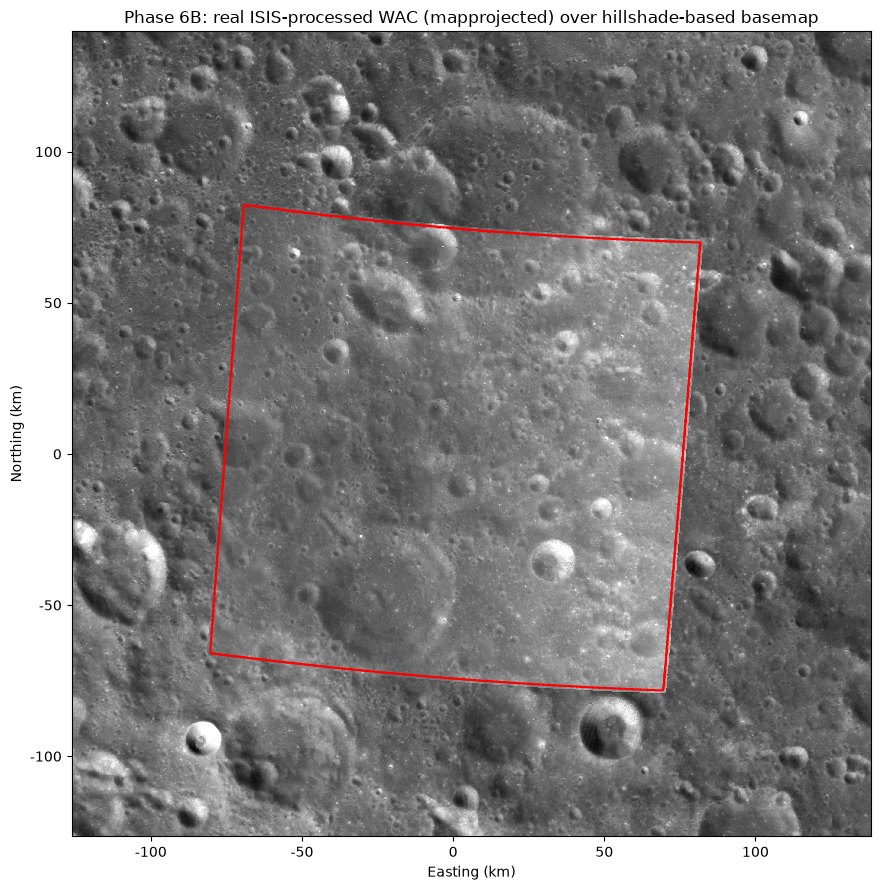

In [17]:
wac_mapproj_tif = isis_wac.run_cam2map_for_crop(wac_crop, lunaserv_result, session.config)
plotting.plot_overlay(
    lunaserv_result.ortho,
    wac_mapproj_tif,
    title="Phase 6B: real ISIS-processed WAC (mapprojected) over hillshade-based basemap",
);

## Phase 7: synthetic render vs. real WAC, side by side

Conceptually, just 5A's and 6A's own render panels (synthetic, real WAC crop -- same tie points, same north-up rotation, computed above) put together directly, for an easier side-by-side look at the two TRN test image candidates themselves, rather than each against the basemap. `plotting.plot_isis_comparison()` additionally brightness-matches the two panels (a single multiplicative scale, since the ISIS cube's calibrated I/F and the render's texture-brightness values are on entirely different numeric scales to begin with -- see its docstring) and interpolates across the real crop's small, known dead-pixel gaps for display -- both real quality-of-life improvements on top of what 5A/6A already show, not new geometry content.

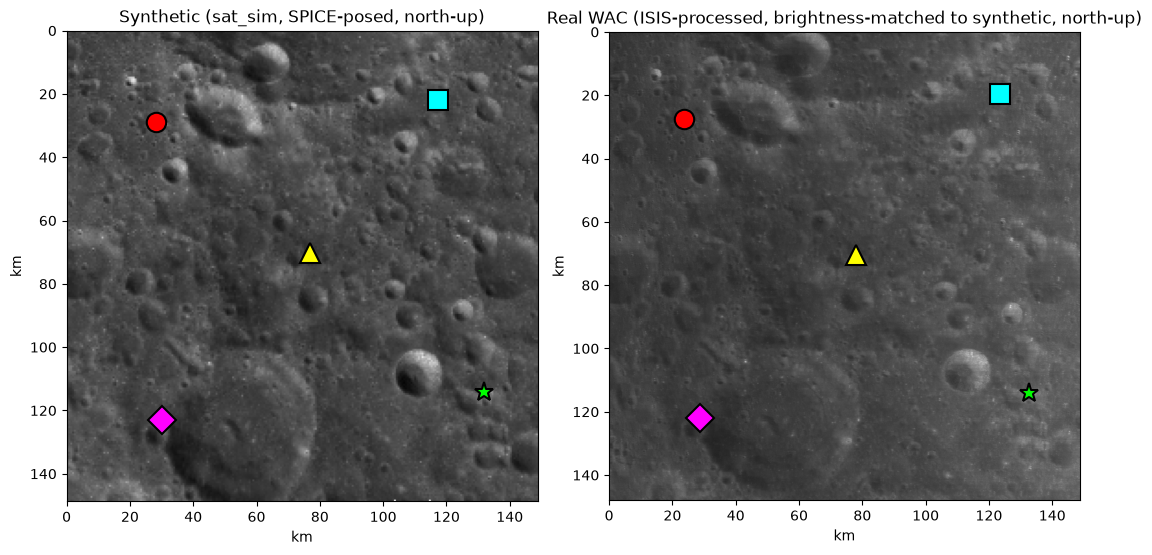

In [18]:
plotting.plot_isis_comparison(camera, tie_point_results, render_result.rendered_tif, wac_crop.cub_path, rotations);

## Summary

- Selected a real, illuminated LROC WAC EDR from a catalog-driven, multi-orbit dataset search (`trntest.dataset.select_dataset`, via the PDS ODE REST API and SPICE-derived orbit/illumination geometry), then computed LRO's true position/orientation at that image's timestamp directly in the Moon's `MOON_ME` frame via `spiceypy`, using a minimal, selectively-cached SPICE kernel set (see `docs/caching.md`).
- Built a `.tsai` Pinhole camera from that pose and rendered a synthetic 256x256 image with ASP's `sat_sim`, fed by real DEM/imagery pulled live from Lunaserv WMS for the camera's own computed ground footprint. Produced a CSM/"ISD" JSON sidecar for it (`cam_gen`), and cross-validated the whole pose pipeline: `cam_gen` independently recovered the same sub-spacecraft geodetic position from the `.tsai`'s raw ECEF pose that the original SPICE computation produced.
- Validated the synthetic render's geometry against the hillshade-based basemap two ways (Phase 5): a raw, north-up-rotated quality check (5A), and a true pixel-for-pixel geo-registered overlay via `mapproject` through the render's own CSM sidecar (5B).
- Processed the same real footprint's WAC EDR through ISIS3's own pipeline (`isis_wac.run_pipeline`) -- a genuine camera-model-based real-WAC product (EDR fetch through calibration and framelet interleaving) -- cropped it to the real footprint being compared (`isis_wac.crop_for_camera`), and validated that single crop's geometry against the same basemap the same two ways (Phase 6): a raw quality check (6A), and a `cam2map` overlay through ISIS's own native Pushframe camera model (6B) -- not ASP's `mapproject`/CSM, after finding a real bug in `usgscsm`'s `groundToImage` for Pushframe sensors.
- Compared the two TRN test image candidates directly against each other, with explicit SPICE-derived tie points (Phase 7).